# I - Imports

In [1]:
import numpy as np
import os
import pandas as pd
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from itertools import product

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up the root directory
root_dir = r"C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition"

os.chdir(root_dir)

os.getcwd()

'C:\\Users\\Source\\OneDrive - IESEG\\Desktop\\MBD\\ML\\Kaggle_Competition'

# II - Loading

In [3]:
train = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'train_preprocessed.csv'), index_col="ID")
train_labels = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'y_train.csv'))
test = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'test_preprocessed.csv'), index_col="ID")

In [4]:
# Verifying the imports
display(train.head(3))
display(train_labels.head(3))
display(test.head(3))

,Var5,Var7,Var11,Var13,Var17,Var19,Var20,Var21,Var22,Var28,...,Var14822_freq,Var14893_freq,Var14904_freq,Var14910_freq,Var14913_freq,Var14923_freq,Var14965_freq,Var14970_freq,Var14990_freq,Var14993_freq
ID,,,,,,,,,,,,,,,,,,,,,
502504,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84608.0,1702392.0,...,0.000167,0.000833,0.000033,0.959833,0.000233,0.5867,0.071467,0.079633,0.082333,0.000833
197332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1481512.0,846372.0,...,0.000067,0.001433,0.007033,0.959833,0.000600,0.5867,0.005167,0.347167,0.082333,0.001433
277830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9176480.0,478698.0,...,0.000033,0.000167,0.002667,0.959833,0.000100,0.5867,0.002233,0.347167,0.028400,0.000167


,ID,Target_appetency
0,502504,0
1,197332,0
2,277830,0


,Var5,Var7,Var11,Var13,Var17,Var19,Var20,Var21,Var22,Var28,...,Var14822_freq,Var14893_freq,Var14904_freq,Var14910_freq,Var14913_freq,Var14923_freq,Var14965_freq,Var14970_freq,Var14990_freq,Var14993_freq
ID,,,,,,,,,,,,,,,,,,,,,
877149,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,495392.0,2592144.0,...,0.000667,0.000600,0.001300,0.959833,0.000700,0.128267,0.089000,0.057333,0.162700,0.000600
109603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23850.0,...,0.001333,0.001767,0.001100,0.959833,0.001367,0.128267,0.009433,0.023033,0.022400,0.001767
560424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14804640.0,1104144.0,...,0.000000,0.000400,0.011567,0.959833,0.000100,0.128267,0.006467,0.014467,0.027333,0.000400


# III - Modeling

## A) Setup

In [5]:
X_train = train.copy()
y_train_arr = train_labels['Target_appetency'].values

# Class imbalance ratio
neg = (y_train_arr == 0).sum()
pos = (y_train_arr == 1).sum()
scale_pos = neg / pos

# our k fold cv 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Computes out-of-fold predictions, then prints classification report and plots confusion matrix. threshold=0.5 is the default probability cutoff.


In [6]:
def evaluate_cv_classifier(model_name, estimator, X, y, cv, threshold=0.5):
    y_proba = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1)[:, 1]

    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n{model_name}  Classification Report")
    print(classification_report(y, y_pred, digits=4))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No appetency", "Appetency"])
    
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix, threshold={threshold}")
    plt.show()

    return y_proba, y_pred

## B) DT

In [7]:
# No scaling, no PCA needed.
# class_weight='balanced' handles imbalance by reweighting splits.
# SMOTE not used for trees as class_weight is more principled as it directly adjusts the impurity criterion, whereas SMOTE generates synthetic points that can mislead tree splits.

dt_pipeline = Pipeline([('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))])

dt_grid = {
    'dt__max_depth': [3, 5, 10],
    'dt__min_samples_leaf': [20, 50],
    'dt__criterion': ['gini'],
    'dt__ccp_alpha': [0.0, 0.001]
}

dt_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)
dt_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__ccp_alpha': [0.0, 0.001], 'dt__criterion': ['gini'], 'dt__max_depth': [3, 5, ...], 'dt__min_samples_leaf': [20, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [8]:
print(f"Best AUC (CV): {dt_search.best_score_:.4f}")
print(f"Best params: {dt_search.best_params_}")

dt_pred = dt_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8071
Best params: {'dt__ccp_alpha': 0.0, 'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__min_samples_leaf': 20}



Decision Tree  Classification Report
              precision    recall  f1-score   support

           0     0.9937    0.7450    0.8515     29466
           1     0.0498    0.7378    0.0933       534

    accuracy                         0.7449     30000
   macro avg     0.5217    0.7414    0.4724     30000
weighted avg     0.9769    0.7449    0.8380     30000



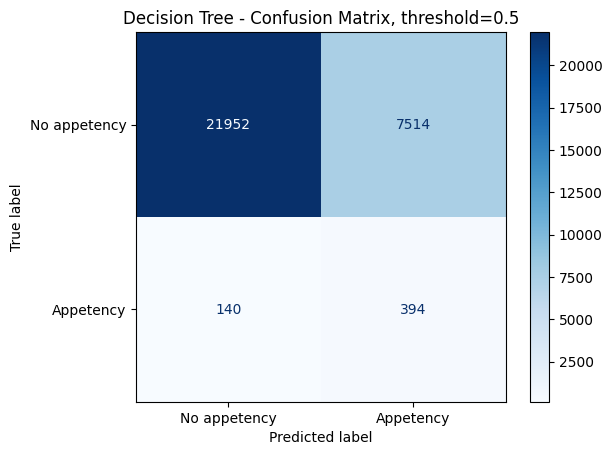

In [9]:
dt_cv_proba, dt_cv_pred = evaluate_cv_classifier(
    "Decision Tree",
    dt_search.best_estimator_,
    X_train,
    y_train_arr,
    cv,
    threshold=0.5
)

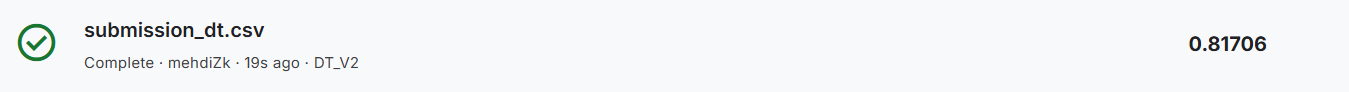

## C) Bagging

In [11]:
# Bagging with DT base estimators.
# max_features and max_samples add randomness on top of bootstrap.
# class_weight passed to base estimator handles imbalance.

base_dt = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=3,
    min_samples_leaf=20,
    ccp_alpha=0.0,
    random_state=42
)

bag_pipeline = Pipeline([('bagging', BaggingClassifier(estimator=base_dt, random_state=42))])

bag_grid = {
    'bagging__n_estimators': [50, 100],
    'bagging__max_samples': [0.7, 1.0],
    'bagging__max_features': [0.5, 0.7]
}

bag_search = GridSearchCV(
    estimator=bag_pipeline,
    param_grid=bag_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)
bag_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bagging__max_features': [0.5, 0.7], 'bagging__max_samples': [0.7, 1.0], 'bagging__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [12]:
print(f"Best AUC (CV): {bag_search.best_score_:.4f}")
print(f"Best params:  {bag_search.best_params_}")

bag_pred = bag_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8455
Best params:  {'bagging__max_features': 0.5, 'bagging__max_samples': 1.0, 'bagging__n_estimators': 100}



Bagging  Classification Report
              precision    recall  f1-score   support

           0     0.9935    0.8194    0.8981     29466
           1     0.0660    0.7041    0.1206       534

    accuracy                         0.8173     30000
   macro avg     0.5297    0.7617    0.5094     30000
weighted avg     0.9770    0.8173    0.8842     30000



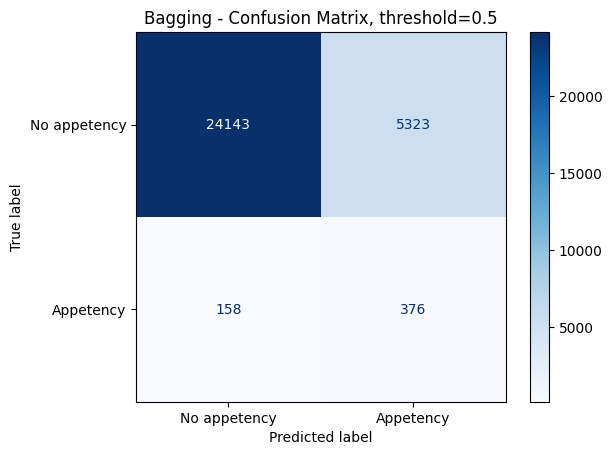

In [13]:
bag_cv_proba, bag_cv_pred = evaluate_cv_classifier(
    "Bagging",
    bag_search.best_estimator_,
    X_train,
    y_train_arr,
    cv,
    threshold=0.5
)

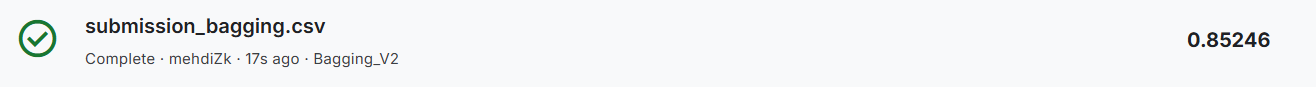

## D) RF

In [15]:
# max_features='sqrt' is the standard RF rule for classification.
# class_weight='balanced_subsample' recomputes weights on each
# bootstrap sample — more appropriate than 'balanced' for RF
# since each tree sees a different bootstrap sample.

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_grid = {
    'rf__n_estimators': [100, 300],
    'rf__max_depth': [10, 20],
    'rf__max_features': ['sqrt', 0.1],
    'rf__min_samples_leaf': [5, 20]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)
rf_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [10, 20], 'rf__max_features': ['sqrt', 0.1], 'rf__min_samples_leaf': [5, 20], 'rf__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [16]:
print(f"Best AUC (CV): {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

rf_pred = rf_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8420
Best params: {'rf__max_depth': 10, 'rf__max_features': 0.1, 'rf__min_samples_leaf': 20, 'rf__n_estimators': 300}



Random Forest  Classification Report
              precision    recall  f1-score   support

           0     0.9869    0.9606    0.9736     29466
           1     0.1204    0.2978    0.1714       534

    accuracy                         0.9488     30000
   macro avg     0.5536    0.6292    0.5725     30000
weighted avg     0.9715    0.9488    0.9593     30000



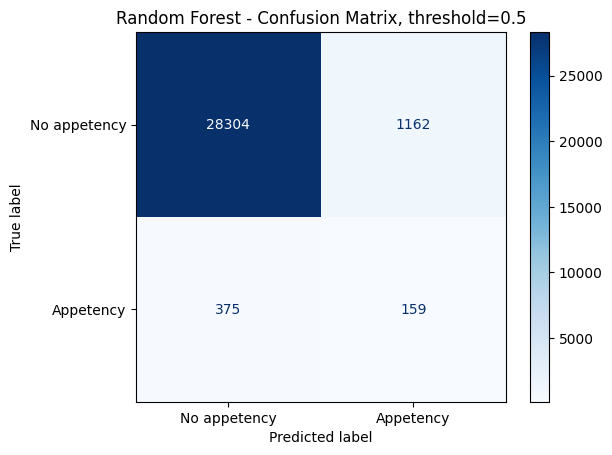

In [17]:
rf_cv_proba, rf_cv_pred = evaluate_cv_classifier("Random Forest", rf_search.best_estimator_, X_train, y_train_arr, cv, threshold=0.5)

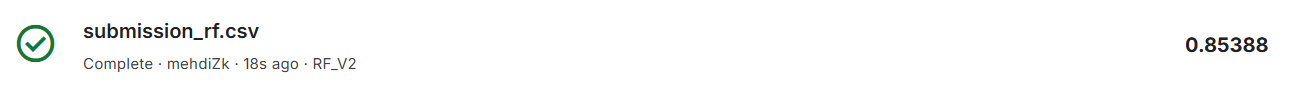

## Exporting the submission CSVs

In [ ]:
# Export Kaggle submission files for DT, Bagging, and RF
submission_dt = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": dt_pred
})

submission_bagging = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": bag_pred
})

submission_rf = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": rf_pred
})

submission_dt.to_csv("output/submission_dt.csv", index=False)
submission_bagging.to_csv("output/submission_bagging.csv", index=False)
submission_rf.to_csv("output/submission_rf.csv", index=False)


display(submission_dt.head())
display(submission_bagging.head())
display(submission_rf.head())

,ID,Target_appetency
0,877149,0.830608
1,109603,0.276423
2,560424,0.341996
3,386592,0.507001
4,857379,0.830608


,ID,Target_appetency
0,877149,0.700193
1,109603,0.363195
2,560424,0.269303
3,386592,0.309309
4,857379,0.602071


,ID,Target_appetency
0,877149,0.448973
1,109603,0.058108
2,560424,0.041883
3,386592,0.058100
4,857379,0.375887
